In [96]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv', encoding='latin1')


In [108]:
df.dropna(subset=['CustomerID'], inplace=True)
df.drop_duplicates(inplace=True)
df.head()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.6+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


InvoiceNo      8872
StockCode      8872
Description    8872
Quantity       8872
InvoiceDate    8872
UnitPrice      8872
CustomerID     8872
Country        8872
dtype: int64
392732
        Cancelled  Non Cancelled
Amount       8872         392732


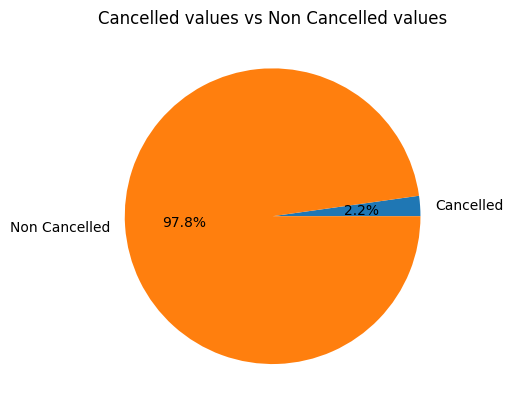

array([  8872, 392732])

In [98]:
df_canceled_invoices = df[df['InvoiceNo'].str.startswith('C')]
print(df_canceled_invoices[df_canceled_invoices['Quantity'] < 0].count())
df_noncanceled_invoices = df[~df['InvoiceNo'].str.startswith('C')]
print(df_noncanceled_invoices.InvoiceNo.count())

chart = pd.DataFrame({ 'Cancelled' : df_canceled_invoices.InvoiceNo.count(), 'Non Cancelled' : df_noncanceled_invoices.InvoiceNo.count()}, index=['Amount'])

print(chart)

plt.figure()
plt.pie(chart.iloc[0].values, labels=chart.columns, autopct= '%1.1f%%')
plt.title('Cancelled values vs Non Cancelled values')
plt.ylabel('')
plt.show()

chart.iloc[0].values

In [99]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [100]:
df.groupby(['CustomerID', 'InvoiceNo'])['InvoiceNo'].count()

CustomerID  InvoiceNo
12346.0     541431        1
            C541433       1
12347.0     537626       31
            542237       29
            549222       24
                         ..
18283.0     579673       50
            580872       50
18287.0     554065       29
            570715       38
            573167        3
Name: InvoiceNo, Length: 22190, dtype: int64

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401604 non-null  object 
 1   StockCode    401604 non-null  object 
 2   Description  401604 non-null  object 
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  object 
 5   UnitPrice    401604 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      401604 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [102]:
pd.DataFrame([{'products' : len(df.StockCode.value_counts()), 
               'transactions': len(df.InvoiceNo.value_counts()),
               'customers' : len(df.CustomerID.value_counts())}], columns=['products', 'transactions', 'customers'], index=['Quantity'])

,products,transactions,customers
Quantity,3684,22190,4372


In [103]:
nb_products_per_basket = ( df.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)
                          .agg(
                              num_line_items=('InvoiceDate', 'count'),
                              num_products = ( 'StockCode', 'nunique' ),
                              total_quantity = ( 'Quantity', 'sum'),
                          ))

nb_products_per_basket.head()

,CustomerID,InvoiceNo,num_line_items,num_products,total_quantity
0,12346.0,541431,1,1,74215
1,12346.0,C541433,1,1,-74215
2,12347.0,537626,31,31,319
3,12347.0,542237,29,29,315
4,12347.0,549222,24,24,483


In [111]:
(
    df.groupby('InvoiceNo')['InvoiceDate']
      .nunique()
      .value_counts()
)


InvoiceDate
1    22159
2       31
Name: count, dtype: int64